In [159]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [160]:
df = pd.read_csv('appointments.csv')
df.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show


In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   appointment_id    200 non-null    object
 1   patient_id        200 non-null    object
 2   doctor_id         200 non-null    object
 3   appointment_date  200 non-null    object
 4   appointment_time  200 non-null    object
 5   reason_for_visit  200 non-null    object
 6   status            200 non-null    object
dtypes: object(7)
memory usage: 11.1+ KB


In [162]:
df.describe()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
count,200,200,200,200,200,200,200
unique,200,48,10,158,40,5,4
top,A001,P012,D005,2023-08-16,11:00:00,Checkup,No-show
freq,1,10,29,5,9,45,52


In [206]:
df.patient_id.nunique()

48

In [212]:
df.patient_id.unique()


array(['P034', 'P032', 'P048', 'P025', 'P040', 'P045', 'P001', 'P016',
       'P039', 'P005', 'P022', 'P029', 'P003', 'P012', 'P026', 'P037',
       'P014', 'P028', 'P047', 'P049', 'P030', 'P046', 'P021', 'P036',
       'P033', 'P023', 'P010', 'P031', 'P019', 'P004', 'P024', 'P002',
       'P027', 'P020', 'P050', 'P035', 'P043', 'P044', 'P013', 'P017',
       'P008', 'P041', 'P007', 'P011', 'P009', 'P018', 'P042', 'P038'],
      dtype=object)

In [164]:
df.sample(10)

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
41,A042,P036,D001,2023-03-21,11:15:00,Emergency,Scheduled
136,A137,P019,D001,2023-10-25,10:00:00,Emergency,No-show
172,A173,P047,D005,2023-06-04,13:30:00,Checkup,Completed
18,A019,P029,D001,2023-02-06,15:30:00,Checkup,Cancelled
39,A040,P010,D009,2023-03-27,12:30:00,Therapy,Completed
30,A031,P026,D006,2023-04-04,10:30:00,Checkup,Completed
85,A086,P017,D002,2023-10-29,11:00:00,Consultation,Cancelled
133,A134,P025,D006,2023-10-17,15:15:00,Consultation,Scheduled
129,A130,P017,D006,2023-02-23,15:00:00,Emergency,No-show
139,A140,P012,D005,2023-02-05,15:15:00,Checkup,No-show


In [165]:
df.notna().sum()

appointment_id      200
patient_id          200
doctor_id           200
appointment_date    200
appointment_time    200
reason_for_visit    200
status              200
dtype: int64

In [166]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool

In [167]:
df.nunique()

appointment_id      200
patient_id           48
doctor_id            10
appointment_date    158
appointment_time     40
reason_for_visit      5
status                4
dtype: int64

In [168]:
df['status'].value_counts()

status
No-show      52
Scheduled    51
Cancelled    51
Completed    46
Name: count, dtype: int64

In [169]:
df['status'].unique()

array(['Scheduled', 'No-show', 'Cancelled', 'Completed'], dtype=object)

In [170]:
df['appointment_date'] = pd.to_datetime(df['appointment_date'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   appointment_id    200 non-null    object        
 1   patient_id        200 non-null    object        
 2   doctor_id         200 non-null    object        
 3   appointment_date  200 non-null    datetime64[ns]
 4   appointment_time  200 non-null    object        
 5   reason_for_visit  200 non-null    object        
 6   status            200 non-null    object        
dtypes: datetime64[ns](1), object(6)
memory usage: 11.1+ KB


In [171]:
df['appointment_time'] = pd.to_datetime(df['appointment_time'], format='%H:%M:%S', errors='coerce').dt.time
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   appointment_id    200 non-null    object        
 1   patient_id        200 non-null    object        
 2   doctor_id         200 non-null    object        
 3   appointment_date  200 non-null    datetime64[ns]
 4   appointment_time  200 non-null    object        
 5   reason_for_visit  200 non-null    object        
 6   status            200 non-null    object        
dtypes: datetime64[ns](1), object(6)
memory usage: 11.1+ KB


In [172]:
df.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show
2,A003,P048,D004,2023-06-28,08:00:00,Consultation,Cancelled
3,A004,P025,D006,2023-09-01,09:15:00,Consultation,Cancelled
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show


In [173]:
df['day_of_week'] = df['appointment_date'].dt.day_name()
df['hour'] = df['appointment_time'].apply(lambda x: x.hour)
df.tail()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status,day_of_week,hour
195,A196,P045,D006,2023-10-26,09:45:00,Checkup,Cancelled,Thursday,9
196,A197,P001,D005,2023-04-01,13:30:00,Emergency,No-show,Saturday,13
197,A198,P022,D006,2023-05-15,08:30:00,Therapy,No-show,Monday,8
198,A199,P017,D001,2023-05-01,12:45:00,Follow-up,Completed,Monday,12
199,A200,P007,D005,2023-12-30,10:15:00,Consultation,Cancelled,Saturday,10


In [174]:
df.values

array([['A001', 'P034', 'D009', ..., 'Scheduled', 'Wednesday', 15],
       ['A002', 'P032', 'D004', ..., 'No-show', 'Friday', 14],
       ['A003', 'P048', 'D004', ..., 'Cancelled', 'Wednesday', 8],
       ...,
       ['A198', 'P022', 'D006', ..., 'No-show', 'Monday', 8],
       ['A199', 'P017', 'D001', ..., 'Completed', 'Monday', 12],
       ['A200', 'P007', 'D005', ..., 'Cancelled', 'Saturday', 10]],
      shape=(200, 9), dtype=object)

In [175]:
df.index

RangeIndex(start=0, stop=200, step=1)

In [176]:
numerical_feature = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_feature = [feature for feature in df.columns if df[feature].dtype == 'O']

In [177]:
numerical_feature, categorical_feature

(['appointment_date', 'hour'],
 ['appointment_id',
  'patient_id',
  'doctor_id',
  'appointment_time',
  'reason_for_visit',
  'status',
  'day_of_week'])

In [178]:
for col in numerical_feature:
    print(f'{col} has {df[col].nunique()} unique values')

appointment_date has 158 unique values
hour has 10 unique values


In [179]:
for col in df.select_dtypes(include='O').columns:
    print(f"\n column: {col}")      
    print(df[col].value_counts())


 column: appointment_id
appointment_id
A001    1
A002    1
A003    1
A004    1
A005    1
       ..
A196    1
A197    1
A198    1
A199    1
A200    1
Name: count, Length: 200, dtype: int64

 column: patient_id
patient_id
P012    10
P005     8
P016     7
P029     7
P036     7
P035     7
P049     7
P026     6
P010     6
P037     6
P023     6
P045     5
P048     5
P039     5
P025     5
P032     5
P019     5
P017     4
P007     4
P022     4
P001     4
P013     4
P024     4
P033     4
P050     4
P031     4
P009     4
P034     3
P047     3
P040     3
P021     3
P046     3
P043     3
P002     3
P028     3
P014     3
P041     3
P030     3
P003     2
P004     2
P044     2
P027     2
P020     2
P008     2
P011     2
P018     2
P042     2
P038     2
Name: count, dtype: int64

 column: doctor_id
doctor_id
D005    29
D001    25
D006    24
D003    22
D002    21
D010    19
D009    17
D008    16
D004    14
D007    13
Name: count, dtype: int64

 column: appointment_time
appointment_time
11:00:00    9
1

In [180]:
df['status'].value_counts()

status
No-show      52
Scheduled    51
Cancelled    51
Completed    46
Name: count, dtype: int64

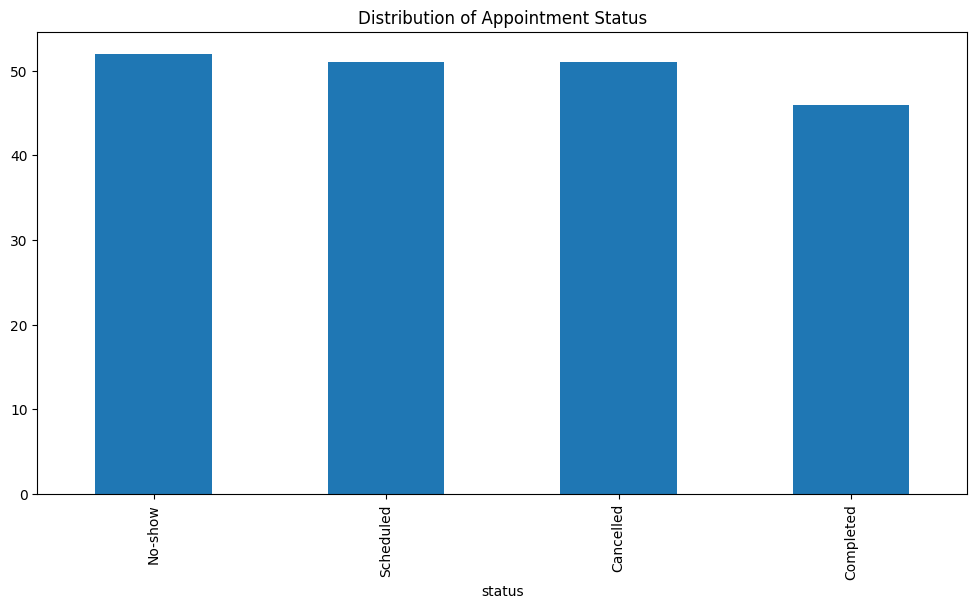

In [181]:
plt.subplots( figsize=(12,6))
df['status'].value_counts().plot(kind='bar')
plt.title('Distribution of Appointment Status')
plt.show()

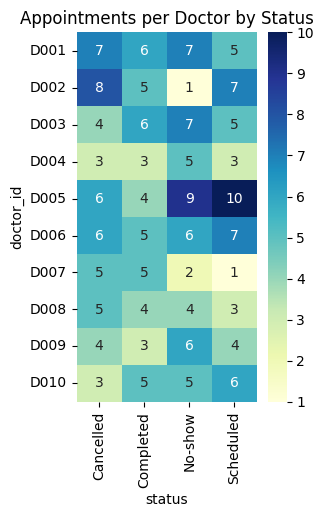

In [182]:
plt.subplot(1,2,2)
pivot = df.pivot_table(index='doctor_id', columns='status', values='appointment_id', aggfunc='count')
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Appointments per Doctor by Status")
plt.show()

In [183]:
df['reason_for_visit'].value_counts()

reason_for_visit
Checkup         45
Consultation    43
Therapy         42
Follow-up       41
Emergency       29
Name: count, dtype: int64

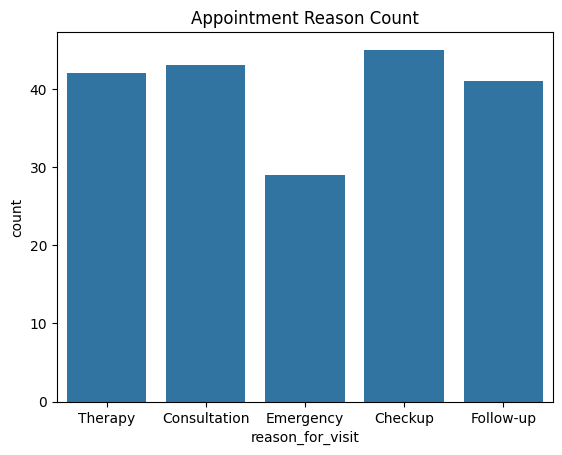

In [184]:
sns.countplot(x='reason_for_visit', data=df)
plt.title('Appointment Reason Count')
plt.show()

In [185]:
df['day_of_week'].value_counts()

day_of_week
Wednesday    37
Tuesday      37
Thursday     28
Sunday       26
Monday       26
Friday       23
Saturday     23
Name: count, dtype: int64

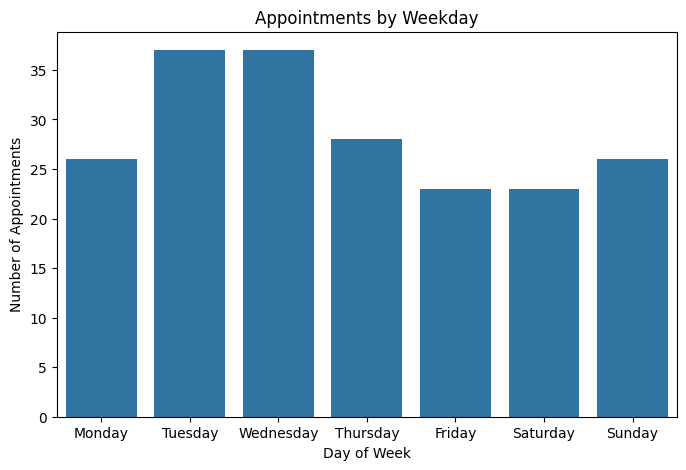

In [186]:
plt.figure(figsize=(8,5))
sns.countplot(x='day_of_week', data=df, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Appointments by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Number of Appointments")
plt.show()


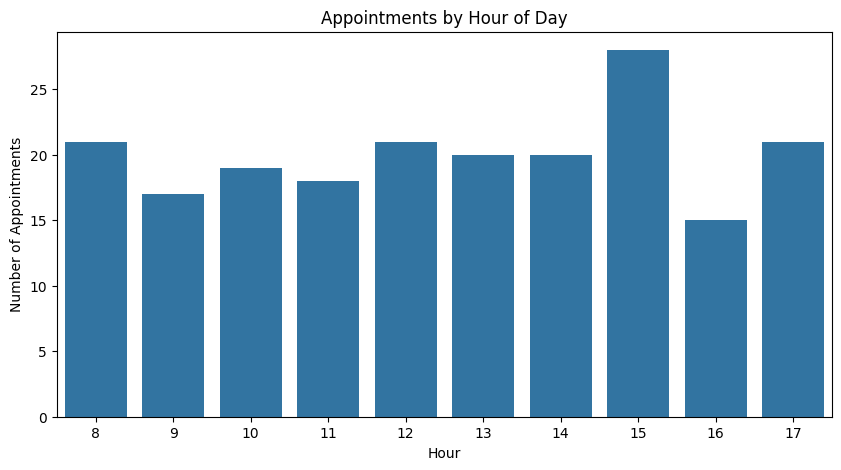

In [187]:
plt.figure(figsize=(10,5))
sns.countplot(x='hour', data=df)
plt.title("Appointments by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Appointments")
plt.show()


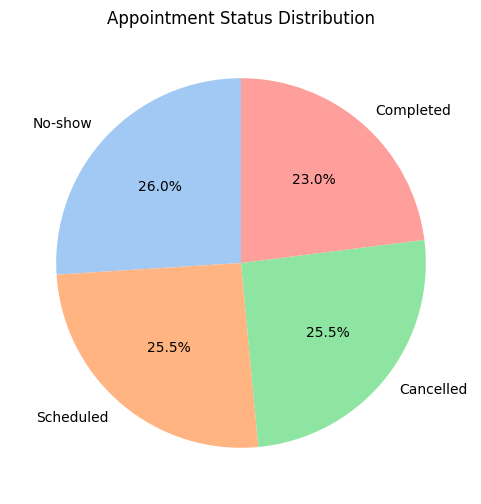

In [188]:
plt.figure(figsize=(6,6))
df['status'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title("Appointment Status Distribution")
plt.ylabel("")
plt.show()


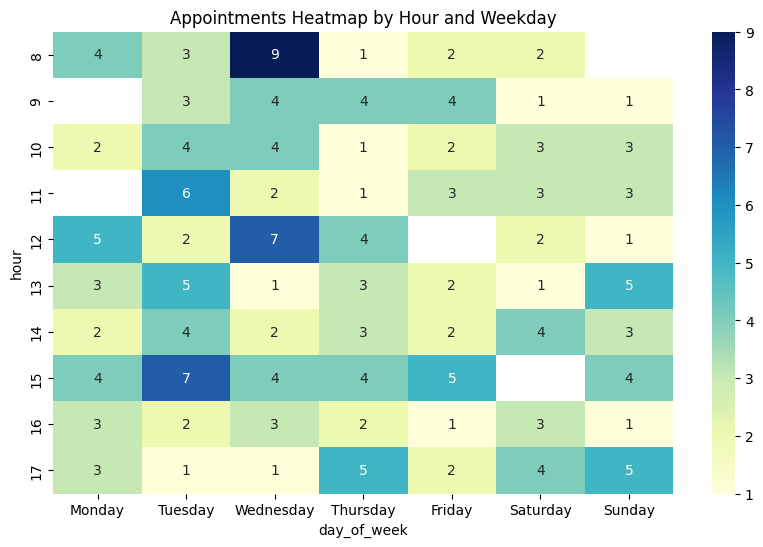

In [189]:
heatmap_data = df.pivot_table(index='hour', columns='day_of_week', values='appointment_id', aggfunc='count')
heatmap_data = heatmap_data[['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']]

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Appointments Heatmap by Hour and Weekday")
plt.show()


In [190]:
heatmap_data = df.pivot_table(
    index='hour',
    columns=['day_of_week','status'],
    values='appointment_id',
    aggfunc='count'
)
print(heatmap_data.head())

day_of_week    Friday                                Monday                    \
status      Cancelled Completed No-show Scheduled Cancelled Completed No-show   
hour                                                                            
8                 1.0       1.0     NaN       NaN       NaN       NaN     2.0   
9                 2.0       NaN     1.0       1.0       NaN       NaN     NaN   
10                NaN       NaN     1.0       1.0       NaN       NaN     1.0   
11                NaN       1.0     1.0       1.0       NaN       NaN     NaN   
12                NaN       NaN     NaN       NaN       1.0       2.0     NaN   

day_of_week            Saturday            ... Thursday             Tuesday  \
status      Scheduled Cancelled Completed  ...  No-show Scheduled Cancelled   
hour                                       ...                                
8                 2.0       1.0       NaN  ...      NaN       1.0       1.0   
9                 NaN       NaN    

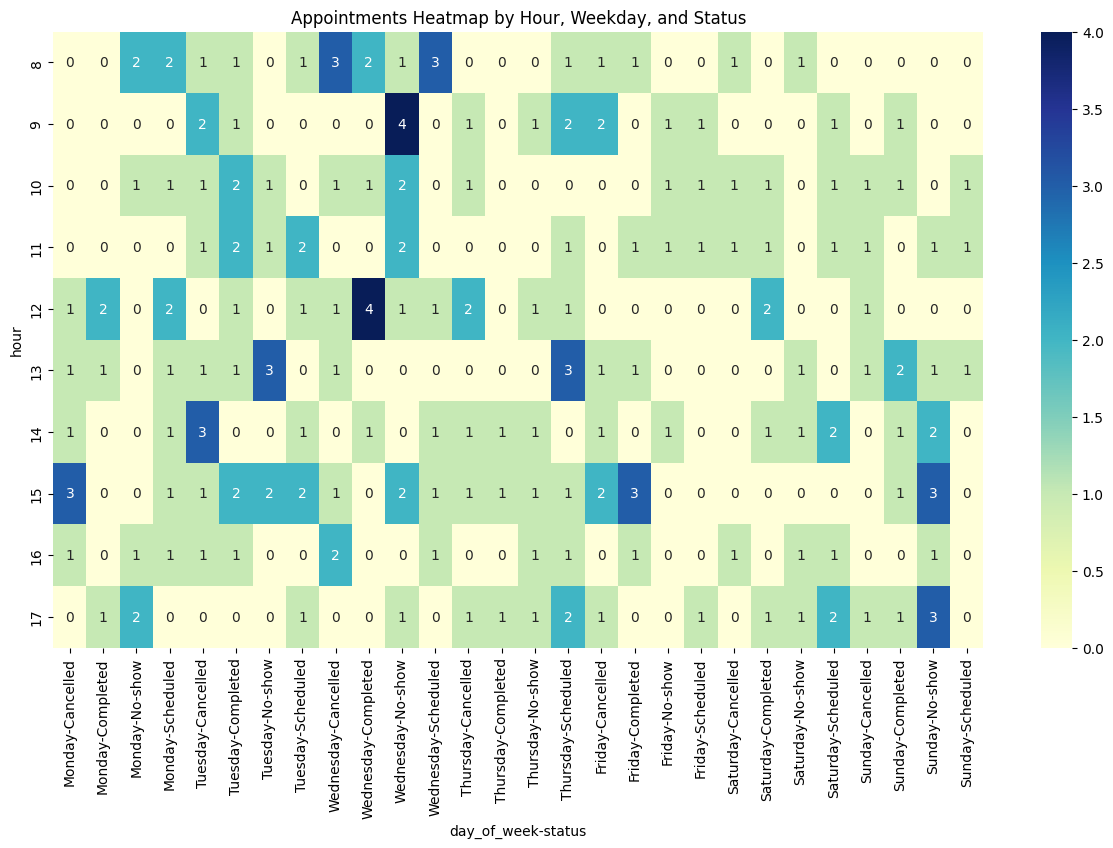

In [191]:
heatmap_data = df.pivot_table(
    index='hour',
    columns=['day_of_week','status'],
    values='appointment_id',
    aggfunc='count'
)

# Reorder weekdays for clarity
heatmap_data = heatmap_data[['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']]

plt.figure(figsize=(15,8))
sns.heatmap(heatmap_data.fillna(0), annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Appointments Heatmap by Hour, Weekday, and Status")
plt.show()


In [192]:


# Pivot table: rows = patient_id, columns = doctor_id, values = number of appointments
patient_doctor_matrix = df.pivot_table(
    index='patient_id',
    columns='doctor_id',
    values='appointment_id',
    aggfunc='count',
    fill_value=0
)

# Show first few rows
print(patient_doctor_matrix)


doctor_id   D001  D002  D003  D004  D005  D006  D007  D008  D009  D010
patient_id                                                            
P001           0     0     0     0     1     1     1     0     1     0
P002           0     1     0     0     0     0     0     1     0     1
P003           0     1     1     0     0     0     0     0     0     0
P004           0     0     1     0     0     1     0     0     0     0
P005           2     0     1     1     1     0     0     0     0     3
P007           0     1     0     0     1     0     0     1     1     0
P008           0     1     0     0     1     0     0     0     0     0
P009           0     0     1     0     0     1     1     0     1     0
P010           0     0     1     0     1     2     0     0     2     0
P011           0     1     0     0     0     0     1     0     0     0
P012           0     2     0     1     1     2     1     1     1     1
P013           0     0     0     0     0     0     0     3     1     0
P014  

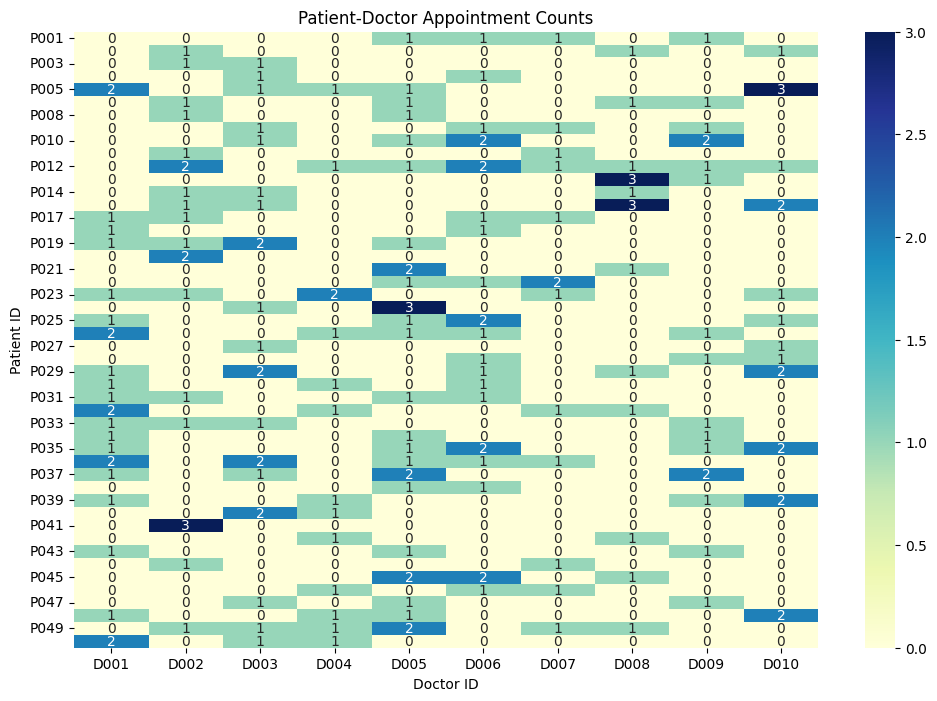

In [193]:
plt.figure(figsize=(12,8))
sns.heatmap(patient_doctor_matrix, cmap="YlGnBu", annot=True, fmt="d")
plt.title("Patient-Doctor Appointment Counts")
plt.xlabel("Doctor ID")
plt.ylabel("Patient ID")
plt.show()


C:\Users\LOQ\AppData\Local\Temp\ipykernel_21660\2964730964.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_matrix = patient_doctor_matrix.applymap(lambda x: 1 if x > 0 else 0)


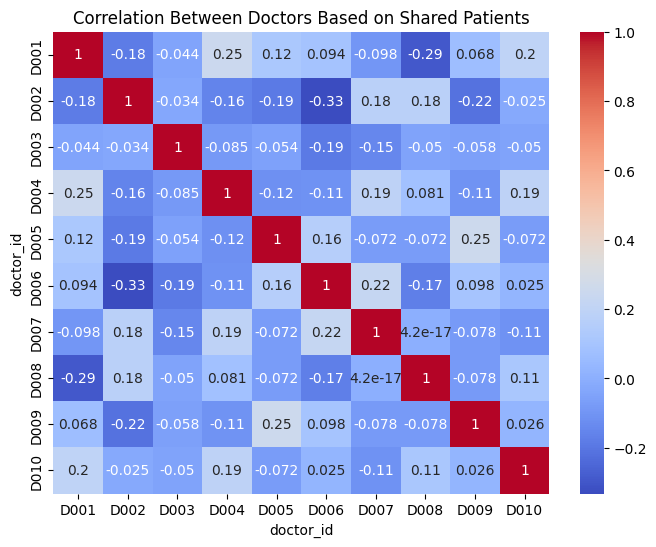

In [194]:
binary_matrix = patient_doctor_matrix.applymap(lambda x: 1 if x > 0 else 0)
doctor_corr = binary_matrix.corr()  # correlation between doctors based on shared patients

plt.figure(figsize=(8,6))
sns.heatmap(doctor_corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Doctors Based on Shared Patients")
plt.show()


In [195]:
# Count appointments per doctor-patient pair
interaction_counts = (
    df.groupby(['doctor_id', 'patient_id'])
      .size()
      .reset_index(name='appointment_count')
)

# Sort descending
interaction_counts = interaction_counts.sort_values(
    by='appointment_count',
    ascending=False
)

# Get the top interaction
top_1= interaction_counts.iloc[0]

print(top_1)


doctor_id            D002
patient_id           P041
appointment_count       3
Name: 34, dtype: object


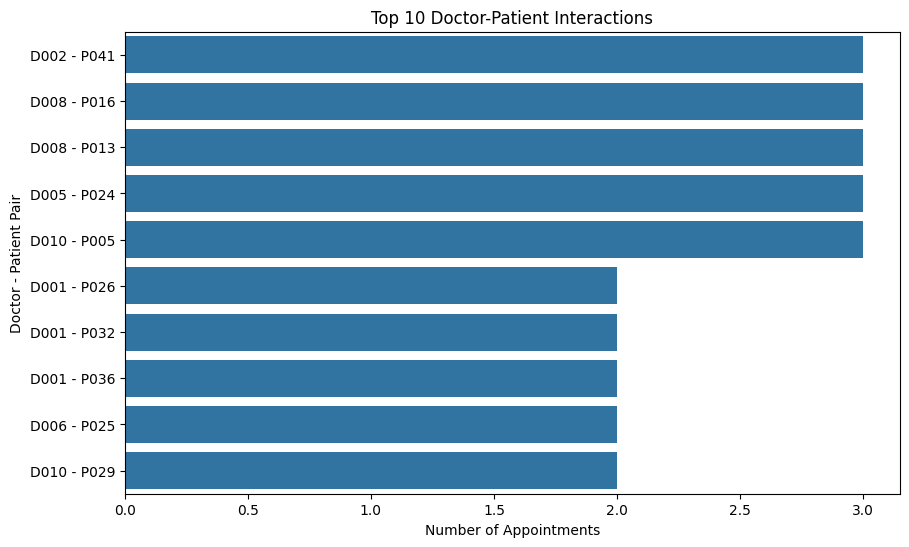

In [196]:
# Step 1: Count appointments per doctor-patient pair
interaction_counts = (
    df.groupby(['doctor_id', 'patient_id'])
      .size()
      .reset_index(name='appointment_count')
)

# Step 2: Sort descending and get top 10
top_10 = interaction_counts.sort_values(
    by='appointment_count',
    ascending=False
).head(10).reset_index(drop=True)

# Step 3: Create pair label
top_10['pair'] = (
    top_10['doctor_id'].astype(str) +
    " - " +
    top_10['patient_id'].astype(str)
)

# Step 4: Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='appointment_count', y='pair', data=top_10)
plt.title("Top 10 Doctor-Patient Interactions")
plt.xlabel("Number of Appointments")
plt.ylabel("Doctor - Patient Pair")
plt.show()

In [197]:
# Count appointments per doctor-patient pair
interaction_counts = (
    df.groupby(['doctor_id', 'patient_id'])
      .size()
      .reset_index(name='appointment_count')
)

# Sort ascending (smallest first)
interaction_counts = interaction_counts.sort_values(
    by='appointment_count',
    ascending=True
)

# Get the least interaction
least_interaction = interaction_counts

print(least_interaction)


    doctor_id patient_id  appointment_count
1        D001       P017                  1
2        D001       P018                  1
3        D001       P019                  1
4        D001       P023                  1
7        D001       P029                  1
..        ...        ...                ...
127      D008       P016                  3
125      D008       P013                  3
77       D005       P024                  3
34       D002       P041                  3
150      D010       P005                  3

[161 rows x 3 columns]


In [198]:
interaction_counts = (
    df.groupby(['doctor_id', 'patient_id'])
      .size()
      .reset_index(name='appointment_count')
      .sort_values(by='appointment_count', ascending=True)
)
print(interaction_counts)



    doctor_id patient_id  appointment_count
1        D001       P017                  1
2        D001       P018                  1
3        D001       P019                  1
4        D001       P023                  1
7        D001       P029                  1
..        ...        ...                ...
127      D008       P016                  3
125      D008       P013                  3
77       D005       P024                  3
34       D002       P041                  3
150      D010       P005                  3

[161 rows x 3 columns]


In [199]:
status_reason_counts = (
    df.groupby(['status', 'reason_for_visit'])
      .size()
      .reset_index(name='appointment_count')
)

print(status_reason_counts)


       status reason_for_visit  appointment_count
0   Cancelled          Checkup                  8
1   Cancelled     Consultation                 15
2   Cancelled        Emergency                  8
3   Cancelled        Follow-up                 10
4   Cancelled          Therapy                 10
5   Completed          Checkup                 16
6   Completed     Consultation                  4
7   Completed        Emergency                  5
8   Completed        Follow-up                 12
9   Completed          Therapy                  9
10    No-show          Checkup                 10
11    No-show     Consultation                 11
12    No-show        Emergency                 10
13    No-show        Follow-up                  6
14    No-show          Therapy                 15
15  Scheduled          Checkup                 11
16  Scheduled     Consultation                 13
17  Scheduled        Emergency                  6
18  Scheduled        Follow-up                 13


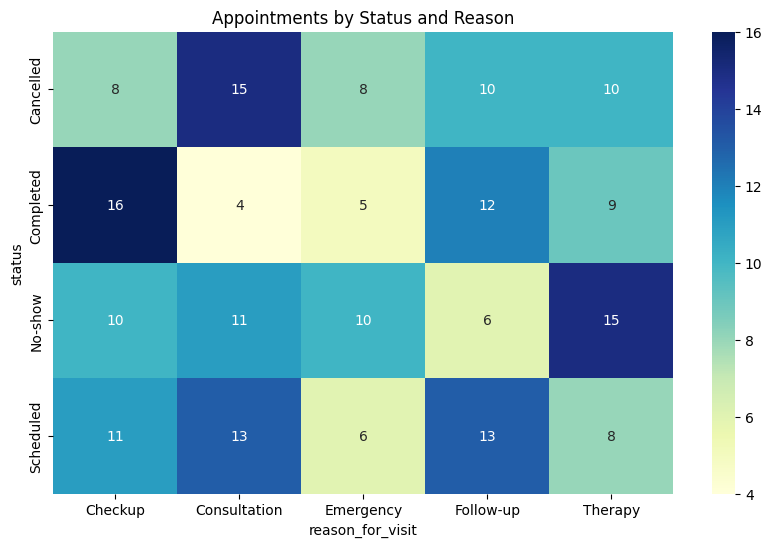

In [200]:
heatmap_data = df.pivot_table(
    index='status',
    columns='reason_for_visit',
    values='appointment_id',
    aggfunc='count',
    fill_value=0
)

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Appointments by Status and Reason")
plt.show()


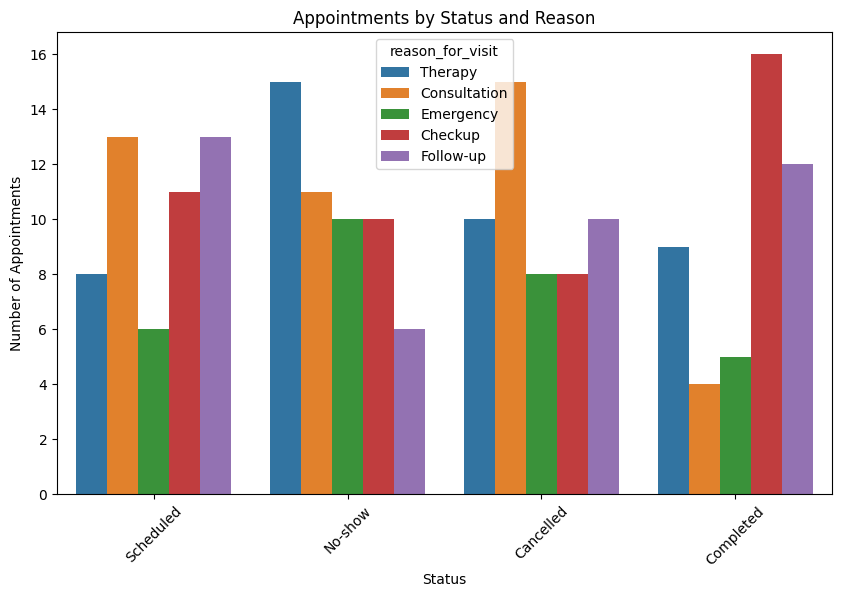

In [201]:


plt.figure(figsize=(10,6))
sns.countplot(data=df, x='status', hue='reason_for_visit')
plt.title("Appointments by Status and Reason")
plt.xlabel("Status")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=45)
plt.show()
